# 10. Gated Context Negative Result: Sparse Rest Validity

A natural reviewer question is: why not let the network learn a gate between OCV-rest evidence and 60 s dynamic history? Sprint 51 tried exactly that. The gate could use rest evidence when valid and fall back to history otherwise.

The negative result is scientifically useful. At `-20 C` in the Scenario A OOD target split, valid rest evidence was sparse: only about `10.38%` of target windows had usable rest anchors in the archived Sprint 51 evaluation. The learned raw gate looked nonzero, but the effective gate was almost zero because most rest evidence was invalid. The model fell back to dynamic history, the same toxic feature family that Sprint 50 showed was not an absolute SOC reference. MaxE reached `69.38%`.

This failure reinforces the observability bottleneck. The architecture can route context, but it cannot fabricate rest-state thermodynamic information when the dataset rarely provides it.


In [1]:
from pathlib import Path
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'src').exists() and (candidate / 'archive').exists():
            return candidate
    raise FileNotFoundError('Could not locate project root containing src/ and archive/.')

ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
FIG_DIR = ROOT / 'outputs' / 'figures' / 'ablation_studies'
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'legend.fontsize': 8.5,
    'legend.frameon': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '-',
})
print(f'Project root: {ROOT}')
print(f'Figure output: {FIG_DIR}')


Project root: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC
Figure output: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies


## Load archived Sprint 51 gated-context results

Sprint 51 was archived during final publication cleanup. This notebook intentionally reads the archived JSON ledger so the negative result stays reproducible.


In [2]:
log_path = ROOT / 'archive' / 'final_publication_purge_20260630' / 'outputs' / 'v7_gated_context' / 'sprint51' / 'sprint51_gated_context_results.json'
if not log_path.exists():
    raise FileNotFoundError(log_path)
payload = json.loads(log_path.read_text(encoding='utf-8'))
evals = payload['evaluation']
rows = []
for key in ['global', 'global_valid_rest', 'global_invalid_rest', 'target', 'target_valid_rest', 'target_invalid_rest']:
    row = evals[key]
    rows.append({
        'Group': row['label'],
        'N windows': row['n_windows'],
        'Full RMSE (%)': row['full_rmse_pct'],
        'Full MaxE (%)': row['full_maxe_pct'],
        'PVR (%)': row['pvr_pct'],
        'Raw gate mean': row['raw_gate_mean'],
        'Effective gate mean': row['effective_gate_mean'],
        'Valid rest rate (%)': row['valid_rate_pct'],
    })
gated_df = pd.DataFrame(rows)
display(gated_df.round(3))
target = evals['target']
assert np.isclose(target['valid_rate_pct'], 10.38003403289847), 'Unexpected Sprint51 -20 C valid rest rate.'
assert np.isclose(target['full_maxe_pct'], 69.38157081604004), 'Unexpected Sprint51 -20 C MaxE.'
assert target['pvr_pct'] == 0.0, 'Gated Hard-Coulomb should preserve zero PVR.'


,Group,N windows,Full RMSE (%),Full MaxE (%),PVR (%),Raw gate mean,Effective gate mean,Valid rest rate (%)
0,Scenario A all-test,18596,18.900,69.382,0.0,0.240,0.035,8.916
1,All-test valid-rest,1658,15.457,29.558,0.0,0.390,0.390,100.000
2,All-test invalid-rest,16938,19.203,69.382,0.0,0.225,0.000,0.000
3,n20degC all,5289,29.693,69.382,0.0,0.369,0.057,10.380
4,n20degC valid-rest,549,24.405,29.558,0.0,0.553,0.553,100.000
5,n20degC invalid-rest,4740,30.246,69.382,0.0,0.348,0.000,0.000


## Warm-temperature control from current v5 contextual arrays

The archived Sprint 51 ledger only reports Scenario A OOD and `-20 C` subgroup metrics. To provide a warm-temperature rest-validity control, this cell computes the `25 C` test rest-valid rate from the current v5 contextual Scenario B arrays. The comparison is a context-availability diagnostic, not a claim that Sprint 51 evaluated `25 C` with the same checkpoint.


In [3]:
scenario_b_dir = ROOT / 'data' / 'processed' / 'v5_contextual' / 'scenario_B'
A_path = scenario_b_dir / 'A_anchor_raw_test.npy'
labels_path = scenario_b_dir / 'temp_labels_test.npy'
if not A_path.exists() or not labels_path.exists():
    raise FileNotFoundError('Missing v5 contextual Scenario B arrays for 25 C rest-valid control.')
A = np.load(A_path)
labels = np.load(labels_path, allow_pickle=True)
valid = A[:, 0] >= 0.5
control_rows = []
for temp, display_name in [('25degC', '25 C control'), ('n20degC', '-20 C Scenario B control')]:
    mask = labels == temp
    control_rows.append({
        'Group': display_name,
        'N windows': int(mask.sum()),
        'Valid rest windows': int(valid[mask].sum()),
        'Valid rest rate (%)': float(valid[mask].mean() * 100.0),
        'Source': str(scenario_b_dir.relative_to(ROOT)),
    })
control_df = pd.DataFrame(control_rows)
display(control_df.round(3))


,Group,N windows,Valid rest windows,Valid rest rate (%),Source
0,25 C control,1626,515,31.673,data\processed\v5_contextual\scenario_B
1,-20 C Scenario B control,872,475,54.472,data\processed\v5_contextual\scenario_B


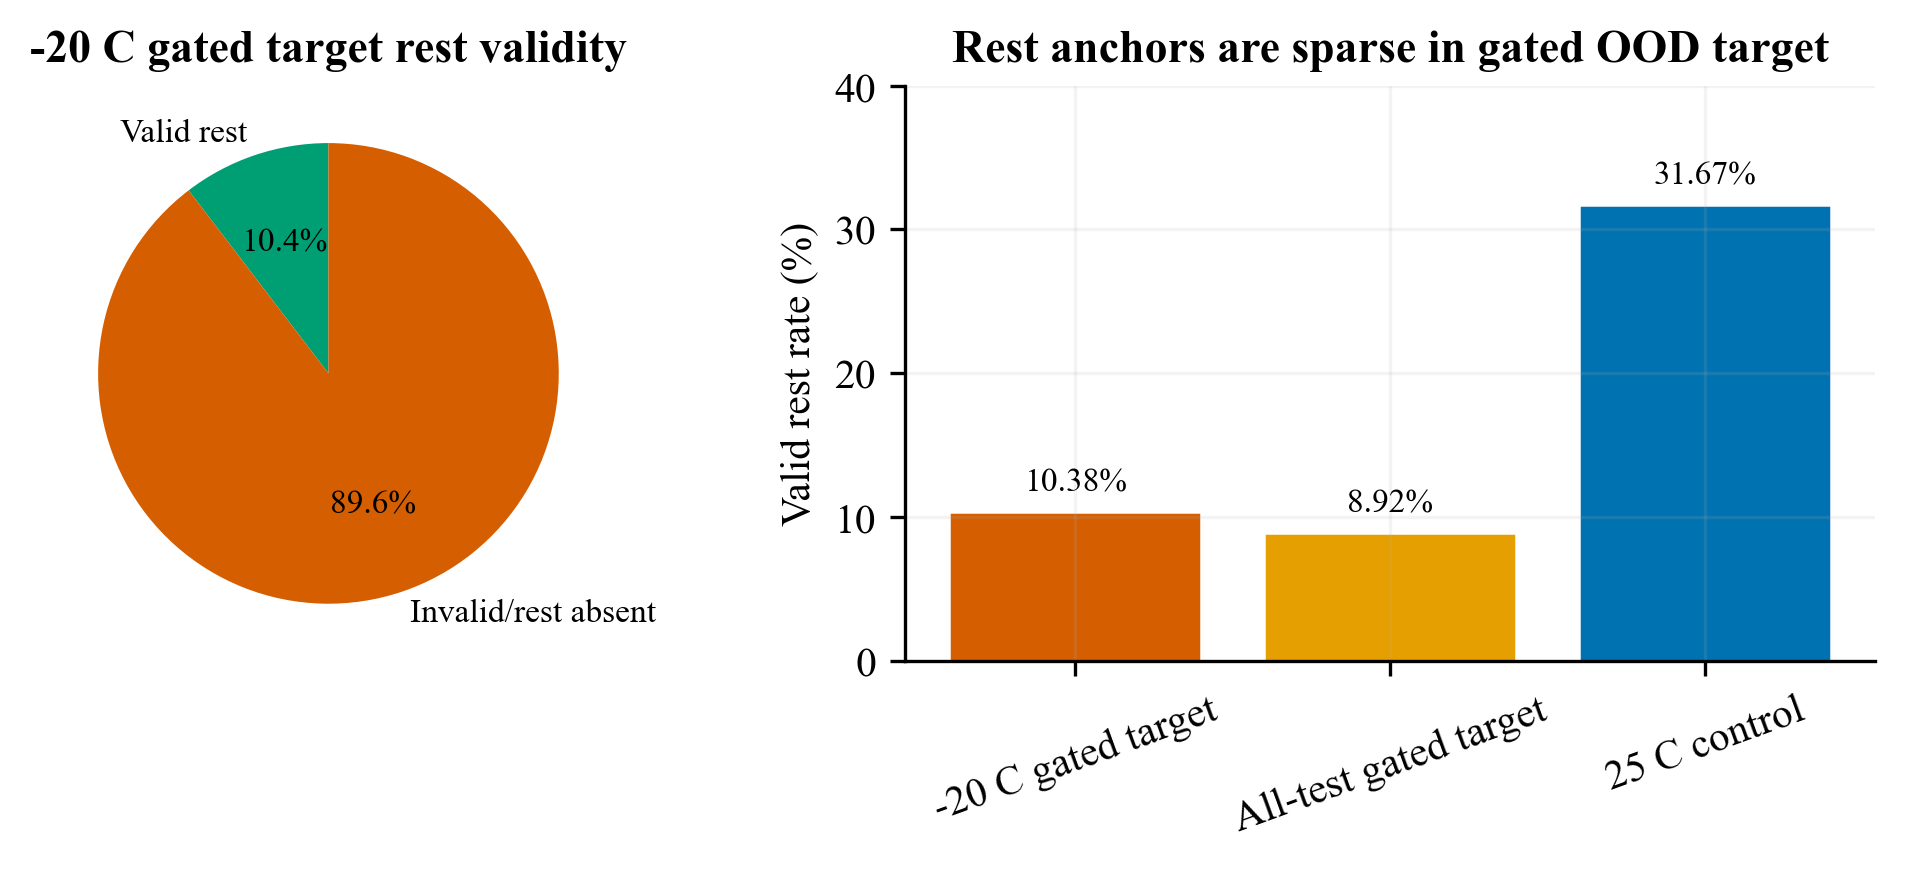

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_10_gated_context_sparse_rest_validity.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_10_gated_context_sparse_rest_validity.png


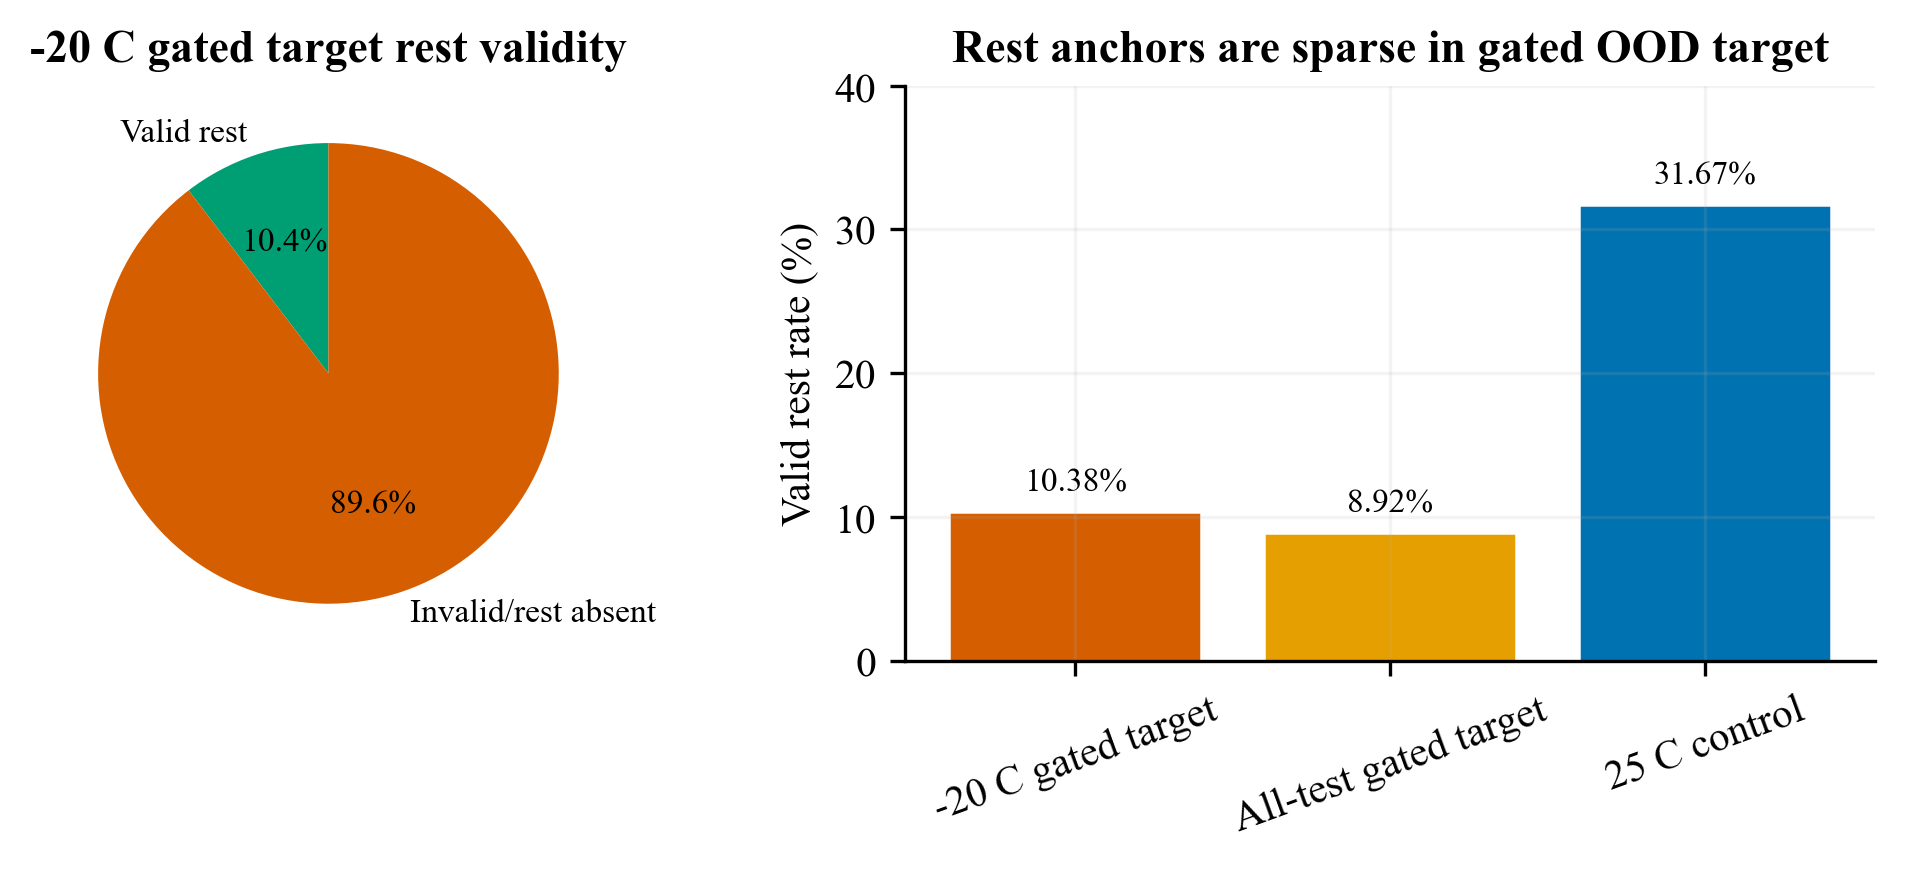

In [4]:
target_valid = int(evals['target_valid_rest']['n_windows'])
target_invalid = int(evals['target_invalid_rest']['n_windows'])
rate_rows = pd.DataFrame([
    {'Group': '-20 C gated target', 'Valid rest rate (%)': evals['target']['valid_rate_pct'], 'Source': 'Sprint51 archived eval'},
    {'Group': 'All-test gated target', 'Valid rest rate (%)': evals['global']['valid_rate_pct'], 'Source': 'Sprint51 archived eval'},
    {'Group': '25 C control', 'Valid rest rate (%)': float(control_df[control_df['Group'] == '25 C control']['Valid rest rate (%)'].iloc[0]), 'Source': 'Current Scenario B arrays'},
])

fig, axes = plt.subplots(1, 2, figsize=(6.75, 3.0), gridspec_kw={'width_ratios': [1.0, 1.25]})
pie_ax = axes[0]
pie_ax.pie(
    [target_valid, target_invalid],
    labels=['Valid rest', 'Invalid/rest absent'],
    autopct='%1.1f%%',
    startangle=90,
    colors=['#009E73', '#D55E00'],
    textprops={'fontsize': 8},
)
pie_ax.set_title('-20 C gated target rest validity')

bar_ax = axes[1]
colors = ['#D55E00', '#E69F00', '#0072B2']
bars = bar_ax.bar(rate_rows['Group'], rate_rows['Valid rest rate (%)'], color=colors, edgecolor='white', linewidth=0.6)
for bar, value in zip(bars, rate_rows['Valid rest rate (%)']):
    bar_ax.text(bar.get_x() + bar.get_width()/2, value + 1.0, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
bar_ax.set_ylabel('Valid rest rate (%)')
bar_ax.set_ylim(0, max(40.0, rate_rows['Valid rest rate (%)'].max() + 8.0))
bar_ax.set_title('Rest anchors are sparse in gated OOD target')
bar_ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_10_gated_context_sparse_rest_validity.pdf'
png_path = FIG_DIR / 'fig_10_gated_context_sparse_rest_validity.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


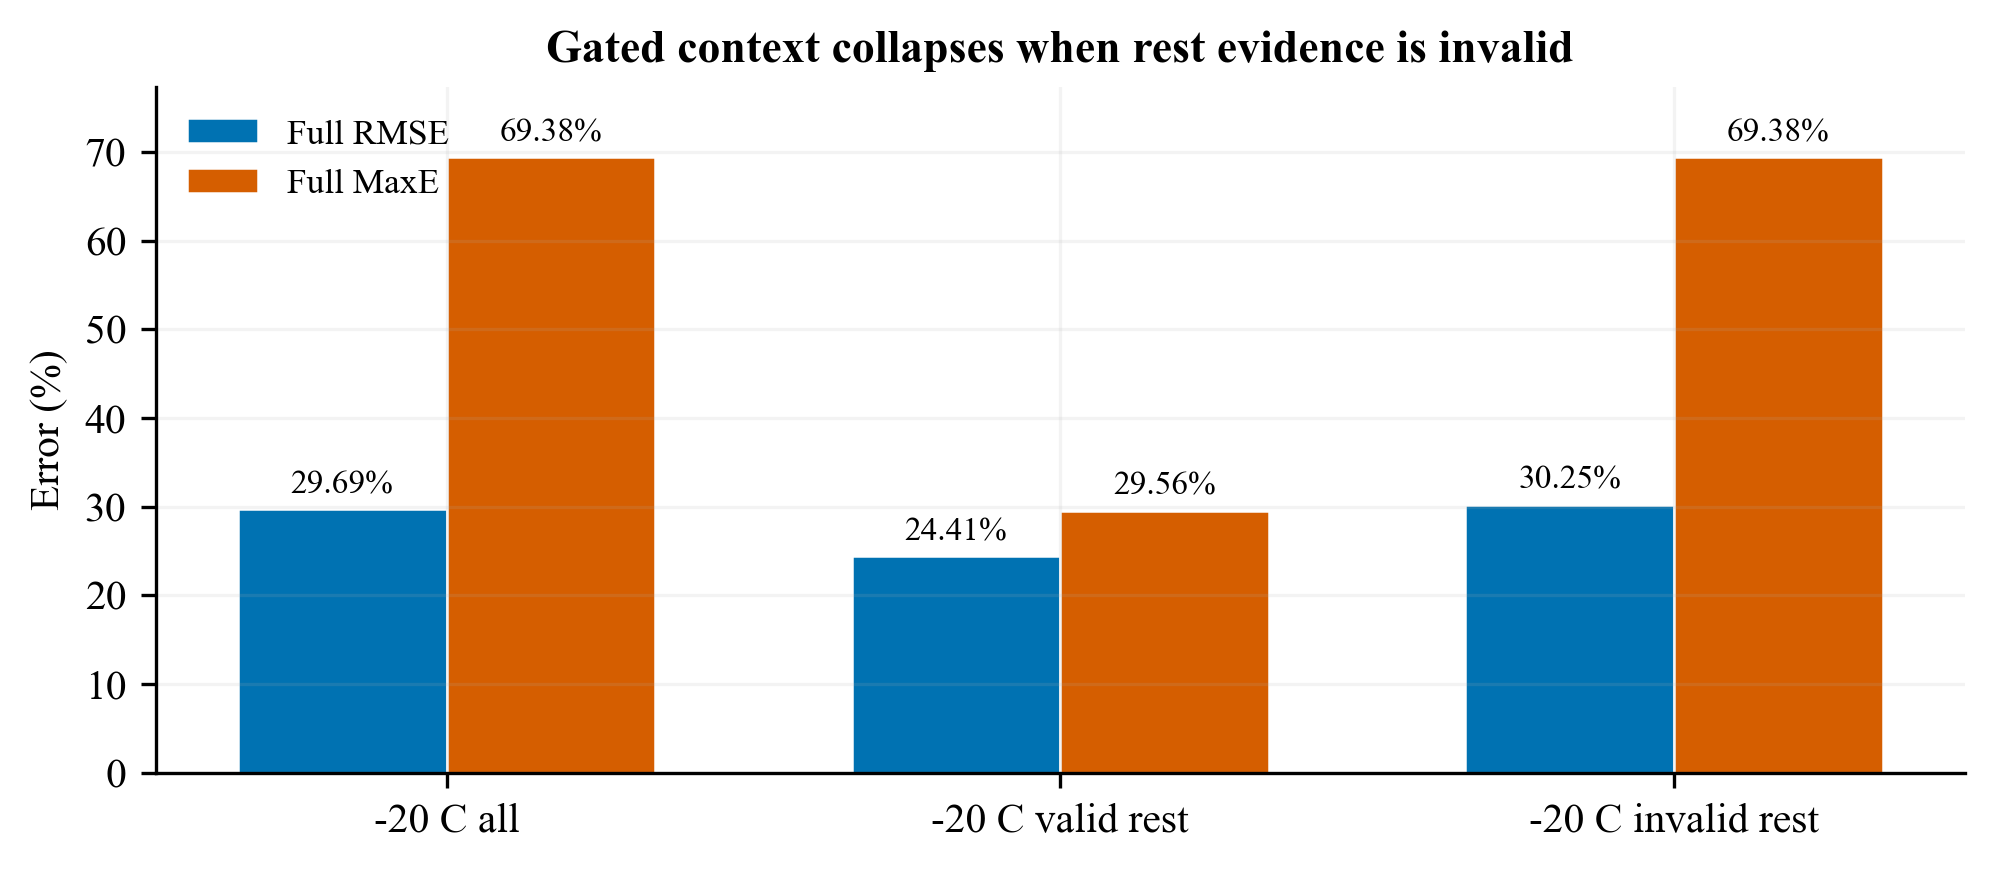

Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_10_gated_context_error_breakdown.pdf
Saved: d:\Tugas kuliah\SEM 6\PROYEK DATA MINING\PENELITIAN\Penelitian_SOC\outputs\figures\ablation_studies\fig_10_gated_context_error_breakdown.png


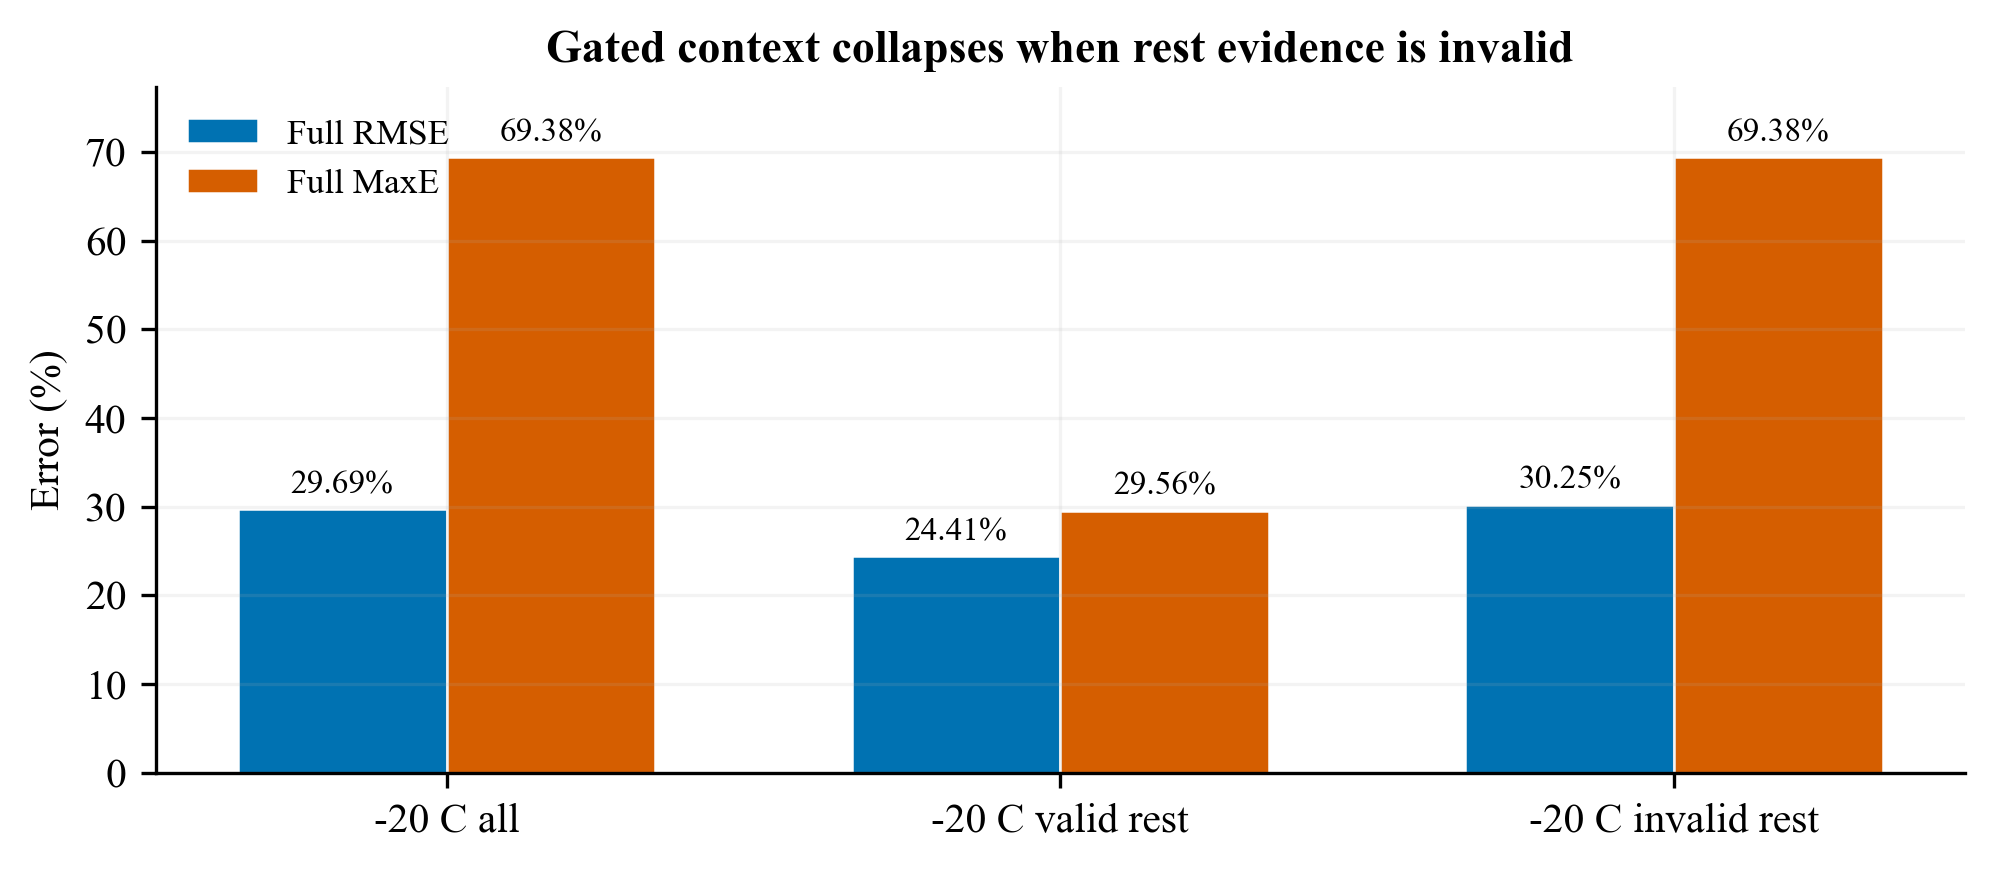

In [5]:
metric_plot = pd.DataFrame([
    {'Group': '-20 C all', 'Full RMSE (%)': evals['target']['full_rmse_pct'], 'Full MaxE (%)': evals['target']['full_maxe_pct']},
    {'Group': '-20 C valid rest', 'Full RMSE (%)': evals['target_valid_rest']['full_rmse_pct'], 'Full MaxE (%)': evals['target_valid_rest']['full_maxe_pct']},
    {'Group': '-20 C invalid rest', 'Full RMSE (%)': evals['target_invalid_rest']['full_rmse_pct'], 'Full MaxE (%)': evals['target_invalid_rest']['full_maxe_pct']},
])
fig, ax = plt.subplots(figsize=(6.75, 3.0))
x = np.arange(len(metric_plot))
width = 0.34
bars1 = ax.bar(x - width/2, metric_plot['Full RMSE (%)'], width=width, color='#0072B2', edgecolor='white', linewidth=0.6, label='Full RMSE')
bars2 = ax.bar(x + width/2, metric_plot['Full MaxE (%)'], width=width, color='#D55E00', edgecolor='white', linewidth=0.6, label='Full MaxE')
for bars in [bars1, bars2]:
    for bar in bars:
        value = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, value + 1.0, f'{value:.2f}%', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x)
ax.set_xticklabels(metric_plot['Group'])
ax.set_ylabel('Error (%)')
ax.set_title('Gated context collapses when rest evidence is invalid')
ax.set_ylim(0, max(75.0, metric_plot['Full MaxE (%)'].max() + 8.0))
ax.legend(loc='upper left')
fig.tight_layout()
pdf_path = FIG_DIR / 'fig_10_gated_context_error_breakdown.pdf'
png_path = FIG_DIR / 'fig_10_gated_context_error_breakdown.png'
fig.savefig(pdf_path)
fig.savefig(png_path, dpi=300)
display(fig)
print(f'Saved: {pdf_path}')
print(f'Saved: {png_path}')


## Autopsy

The gated architecture failed for data-availability reasons, not because gating is conceptually invalid. Valid OCV-rest evidence was too sparse in the cold OOD target. When rest evidence was unavailable, the effective gate collapsed and the model relied on dynamic history, which Sprint 50 already showed is a poor absolute SOC anchor at `-20 C`.
